# Gradient Descent

Gradient Descent is an **optimization algorithm** that finds the minimum of a function by taking steps in the direction of the steepest descent (negative gradient).

> Why Use Gradient Descent with Linear Regression?

Linear Regression tries to find the best line `y=w.x+b` that fits data. We measure "best" using **Mean Squared Error (MSE)**. We need to find `w` and `b` that minimizes this loss. Gradient Descent automatically finds these optimal values.


## Batch Gradient Descent

- Uses all training data to compute each gradient
- **Pro**: Stable, accurate gradient function
- **Con**: slow for large datasets (must process ALL data per update)

## Stochastic Gradient Descent

- Uses one random sample to compute each gradient
- **Pro**: Very fast updates, handles huge datasets
- **Cons**: Noisy updates, may oscillate

## Mini-Batch Gradient Descent

- Uses a small batch of samples
- **Pro**: Balanced - faster than Batch, less noisy than SGD
- **Con**: Need to choose batch size


Training different GD variants...


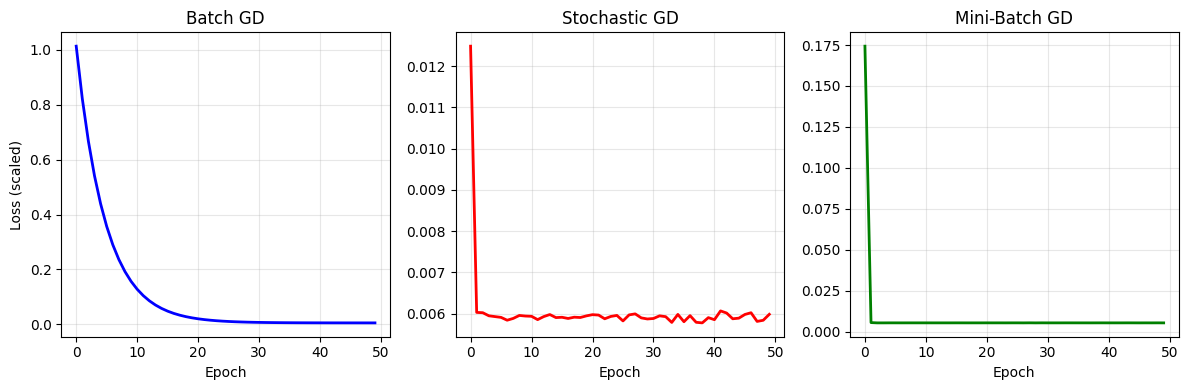


=== Final Results (original scale) ===
Batch GD:      w = 3.4716, b = 1.2365
Stochastic GD: w = 3.5656, b = 1.1367
MiniBatch GD:  w = 3.5083, b = 1.2242
True values:   w = 3.5, b = 1.2


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class LinearRegression: #Optimizing linear regression with gradient descent
    def __init__(self, lr=0.01, batch_size=32):
        self.lr = lr
        self.w = None
        self.b = None

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred)**2) # MSE = \sum_{i=1}^n (y_true,i-y_pred,i)^2

class BatchGD(LinearRegression):
    def fit(self, X, y, epochs=100):
        n_samples, n_features = X.shape
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0
        self.loss_history = []

        for epoch in range(epochs):
            # Predict all samples
            y_pred = self.predict(X)

            # Compute gradient with all samples
            error = y_pred - y
            dw = np.dot(X.T, error) / n_samples
            db = np.mean(error)

            # Update
            self.w -= self.lr * dw
            self.b -= self.lr * db

            self.loss_history.append(self.loss(y, y_pred))

        return self

class StochasticGD(LinearRegression):
    def fit(self, X, y, epochs=100):
        n_samples, n_features = X.shape
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0
        self.loss_history = []

        for epoch in range(epochs):
            epoch_loss = 0
            indices = np.random.permutation(n_samples)

            for i in indices:
                xi = X[i:i+1]
                yi = y[i:i+1]

                y_pred = self.predict(xi)

                error = y_pred - yi
                dw = np.dot(xi.T, error)
                db = np.mean(error)

                # Update after each sample
                self.w -= self.lr * dw
                self.b -= self.lr * db

                epoch_loss += self.loss(yi, y_pred)
            
            self.loss_history.append(epoch_loss / n_samples)

        return self

class MiniBatchGD(LinearRegression):
    def fit(self, X, y, epochs=100, batch_size=32):
        n_samples, n_features = X.shape
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0
        self.loss_history = []

        for epoch in range(epochs):
            epoch_loss = 0
            indices = np.random.permutation(n_samples)

            # Process in batches:
            for start in range(0, n_samples, batch_size):
                end = min(start + batch_size, n_samples)
                batch_idx = indices[start:end]

                X_batch = X[batch_idx]
                y_batch = y[batch_idx]

                y_pred = self.predict(X_batch)

                error = y_pred - y_batch
                dw = np.dot(X_batch.T, error) / len(y_batch)
                db = np.mean(error)

                self.w -= self.lr * dw
                self.b -= self.lr * db

                epoch_loss += self.loss(y_batch, y_pred) * len(y_batch) # weighted sum

            self.loss_history.append(epoch_loss / (n_samples)) # average over all samples

        return self

# Create data
np.random.seed(42)
n_samples = 1000
X = 2 * np.random.randn(n_samples, 1)
true_w = 3.5
true_b = 1.2
y = true_w * X + true_b + np.random.randn(n_samples, 1) * 0.5

# Flatten and scale
X = X.flatten()
y = y.flatten()
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X.reshape(-1,1)).flatten() #(1000, 1)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).flatten() #(1000, 1)

print("Training different GD variants...")

batch_gd = BatchGD(lr=0.1)
stochastic_gd = StochasticGD(lr=0.1)
minibatch_gd = MiniBatchGD(lr=0.1, batch_size=32)

batch_gd.fit(X_scaled.reshape(-1, 1), y_scaled, epochs=50)
stochastic_gd.fit(X_scaled.reshape(-1, 1), y_scaled, epochs=50)
minibatch_gd.fit(X_scaled.reshape(-1, 1), y_scaled, epochs=50)

def recover_original_params(model, scaler_X, scaler_y):
    w_scaled = model.w[0]
    b_scaled = model.b
    sigma_y = scaler_y.scale_[0]
    sigma_x = scaler_X.scale_[0]
    mu_y = scaler_y.mean_[0]
    mu_x = scaler_X.mean_[0]
    
    w_original = w_scaled * (sigma_y / sigma_x)
    b_original = mu_y + b_scaled * sigma_y - w_original * mu_x
    return w_original, b_original

w_batch, b_batch = recover_original_params(batch_gd, scaler_X, scaler_y)
w_stoch, b_stoch = recover_original_params(stochastic_gd, scaler_X, scaler_y)
w_mini, b_mini = recover_original_params(minibatch_gd, scaler_X, scaler_y)

# Plot loss (on scaled data)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(batch_gd.loss_history, 'b-', linewidth=2)
plt.title("Batch GD")
plt.xlabel('Epoch')
plt.ylabel('Loss (scaled)')
plt.grid(True, alpha=0.3)

plt.subplot(1,3,2)
plt.plot(stochastic_gd.loss_history, 'r-', linewidth=2)
plt.title('Stochastic GD')
plt.xlabel('Epoch')
plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
plt.plot(minibatch_gd.loss_history, 'g-', linewidth=2)
plt.title('Mini-Batch GD')
plt.xlabel('Epoch')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Final Results (original scale) ===")
print(f"Batch GD:      w = {w_batch:.4f}, b = {b_batch:.4f}")
print(f"Stochastic GD: w = {w_stoch:.4f}, b = {b_stoch:.4f}")
print(f"MiniBatch GD:  w = {w_mini:.4f}, b = {b_mini:.4f}")
print(f"True values:   w = {true_w}, b = {true_b}")